**Data Science, Data Analytics**

Data analysis, visualization, and transformation

To create models, it is important to understand tools, techniques, processes, libs, framweworks. One of the most important library is **scikit-learn (sklearn)** which is a toolkit for predictive data analysis. Here are some functionalities that will be used:

* Training, Validation and Testing sets.
* Preprocessing
* Feature Enginering
* Canalization: Composers and/or Pipelines
* Linear Regression
* Metrics: MSE, RMSE, R2

<br/>

* Types of data analysis:
    * Descriptive (What happened)
    * Diagnosis (Why happened)
    * Predictive (What will happen)
    * Prescriptive (What will do)

* Models:
    * Supervised Learning (Clasification, Regression)
    * Unsupervised Learning (Clustering/Groups)
    * Forecasting (Time Series)
    * Anomaly Detection (Outliers)

#### Author: Victor Villa

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Let's use next dataset `bigmart.csv`. It is BigMart sales data (collected in 2013) for numerous products across many stores in several cities.

* `Item_Identifier`: ID unique product number
* `Item_Weight`: Item weigth in grams
* `Item_Fat_Content`: Fat content: Low Fat | Regular
* `Item_Visibility`: Placement value for each item, from 0 (far and behind) to 1 (Near and front). The total percentage excibition for all products in a store.
* `Item_Type`: Category of item utility.
* `Item_MRP`: Maximum Retail Price (list price)
* `Outlet_Identifier`: ID unique outlet/store/supermarket name
* `Outlet_Establishment_Year`: Year of outlet establishment.
* `Outlet_Size`: Size of the outlet: small | medium | high.
* `Outlet_Location_Type`: Tier of outlet location: 1 | 2 | 3.
* `Outlet_Type`: Type of outlet: Grocery Store | Supermarket Type1 | Supermarket Type2 | Supermarket Type3.

* **`Item_Outlet_Sales`**: Product sales in a concrete outlet. This is the output variable to predict.

Reference: https://www.kaggle.com/datasets/yasserh/bigmartsalesdataset

In [2]:
# Data manipulation libraries
import numpy as np
import pandas as pd
from datetime import date

# Data visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Model Selection Library
from sklearn.model_selection import train_test_split

# Preprocessing and Feature Engineering Libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Canalization Libraries: Compose and Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Regression and Metrics Llibaries.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

Donwload the csv file: `bigmart.csv` and save it as a dataframe (`df`).

In [3]:
df = pd.read_csv('/content/drive/MyDrive/AI-LearningPath/bigmart.csv')
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
# Number of unique values per column
df.nunique()

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


Since `Item_Identifier` and `Outlet_Identifier` are just IDs, let's assume they do not have value to predict the dependent variable: `Item_Outlet_Sales`.

In [6]:
df.drop(['Item_Identifier','Outlet_Identifier'], axis=1, inplace=True)

In [7]:
# Descriptive statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


In [8]:
# Descriptive statistics for object/text variables
df.describe(include = 'object').T

,count,unique,top,freq
Item_Fat_Content,8523,5,Low Fat,5089
Item_Type,8523,16,Fruits and Vegetables,1232
Outlet_Size,6113,3,Medium,2793
Outlet_Location_Type,8523,3,Tier 3,3350
Outlet_Type,8523,4,Supermarket Type1,5577


In [9]:
# Let's make two lists, one for numerical variables and other for categorical variables.
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [10]:
# Count values by unique category for each category variable
for column in cat_cols:
    print(column)
    print(df[column].value_counts())
    print('-' * 50)

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------
Outlet_Size
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64
--------------------------------------------------
Outlet_Location_Type
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388

In [11]:
# get null values percentage per column
df.isnull().mean() * 100

,0
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000
Outlet_Type,0.000000
Item_Outlet_Sales,0.000000


**Univariate analysis for numerical variables**

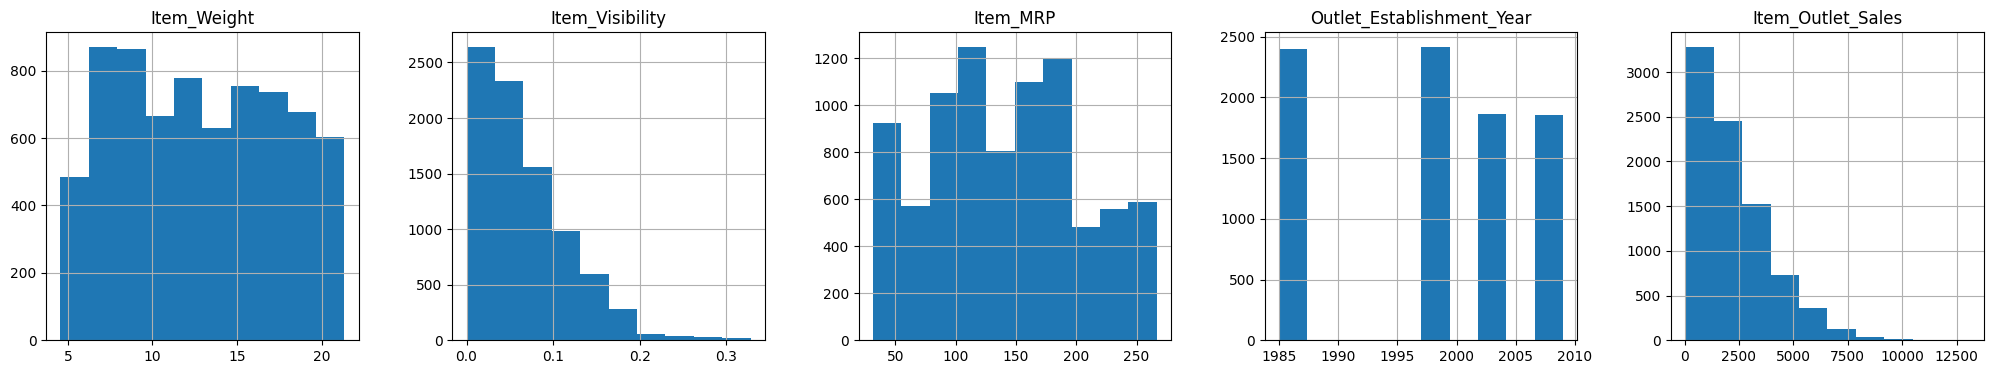

In [12]:
df.hist(figsize=(25,4), layout=(1,5))
plt.show()

/tmp/ipykernel_80738/3559059353.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col].dropna(), labels=[f'{col}'])
/tmp/ipykernel_80738/3559059353.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col].dropna(), labels=[f'{col}'])
/tmp/ipykernel_80738/3559059353.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col].dropna(), labels=[f'{col}'])
/tmp/ipykernel_80738/3559059353.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col].d

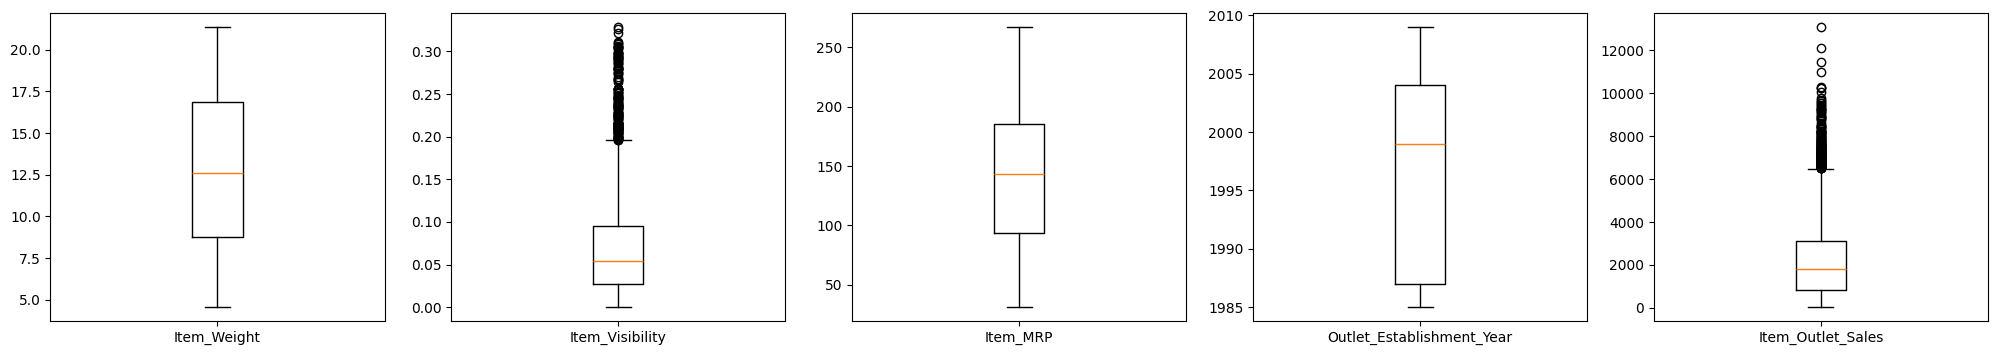

In [13]:
fig, axes = plt.subplots(1,5, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  ax.boxplot(df[col].dropna(), labels=[f'{col}'])

**Univariate analysis fo categorical variables**

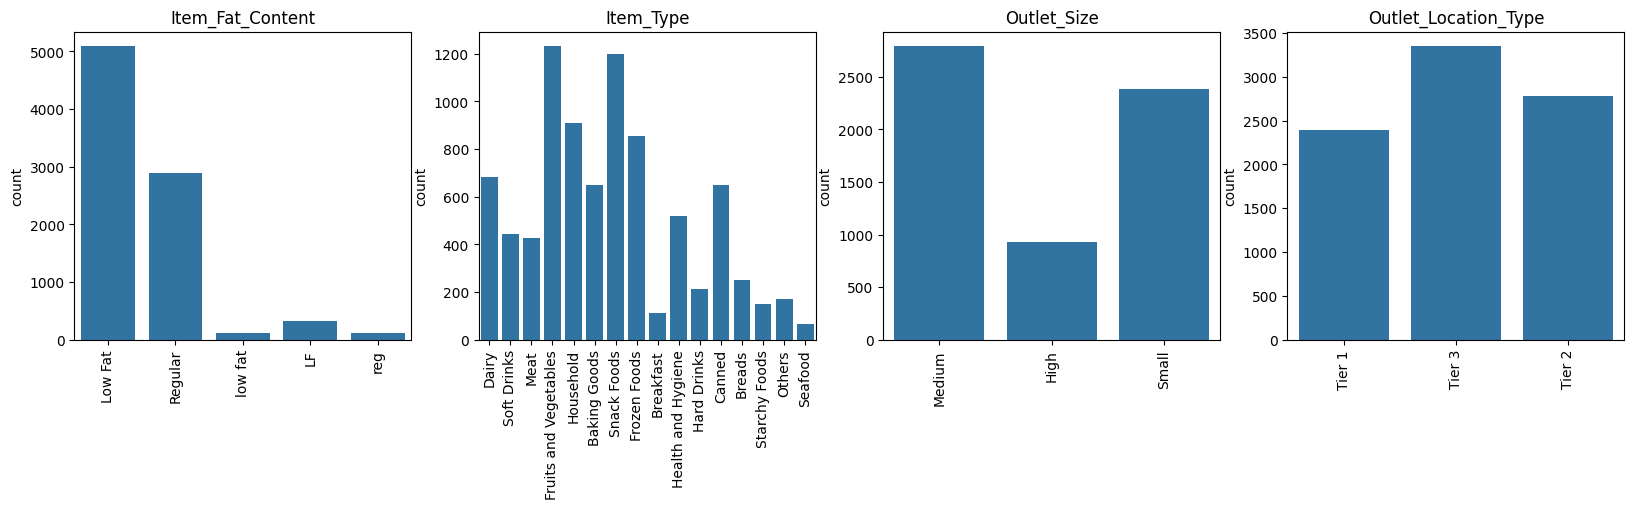

In [14]:
fig, axes = plt.subplots(1,4, figsize=(20,4))
axes = axes.ravel()
for col, ax in zip(df[cat_cols], axes):
  sns.countplot(x=df[col], ax=ax)
  ax.set(title=f'{col}', xlabel=None)
  ax.tick_params(axis='x',rotation=90)

In `Item_Fat_Content` there are categories typed in different ways but mean the same:
* Low Fat = low fat = LF
* Regular = reg

Let's unify/merge them to leave just two values: Low Fat and Regular

In [15]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].apply(lambda x: 'Low Fat' if x == 'low fat' or x == 'LF' else x)
df['Item_Fat_Content'] = df['Item_Fat_Content'].apply(lambda x: 'Regular' if x == 'reg' else x)

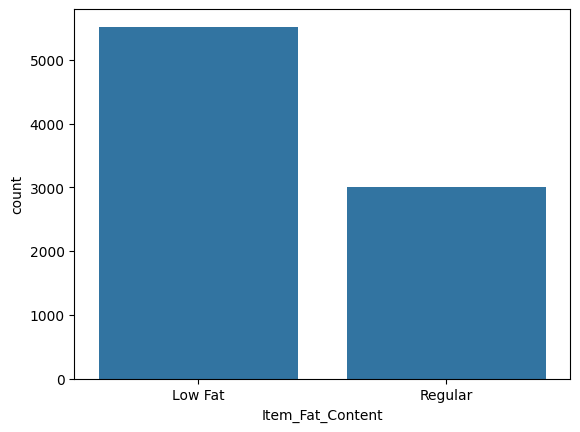

In [16]:
sns.countplot(x=df['Item_Fat_Content'])
plt.show()

**Bivariate analysis**

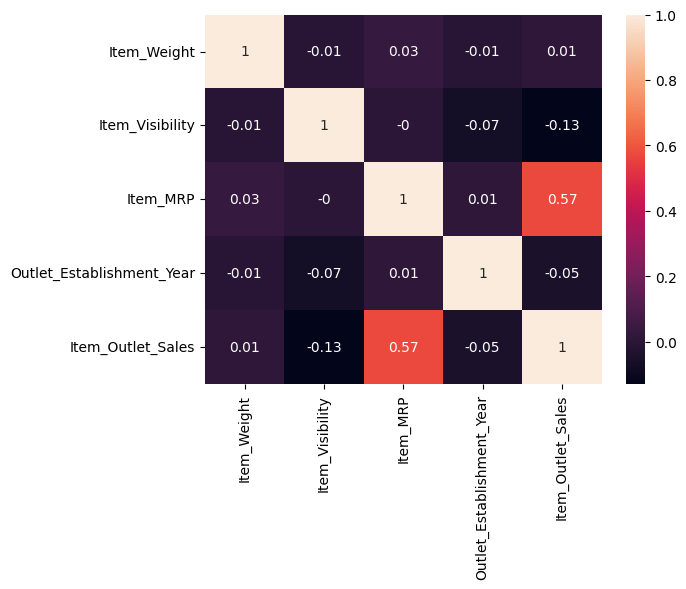

In [17]:
sns.heatmap(round(df.corr(numeric_only=True),2), annot = True)
plt.show()

From previous plot, it looks like the independent variable `Item_MRP` has a moderate lineal relationship with the dependent variable `Item_Outlet_Sales`. Let's check it out with scatter plots.

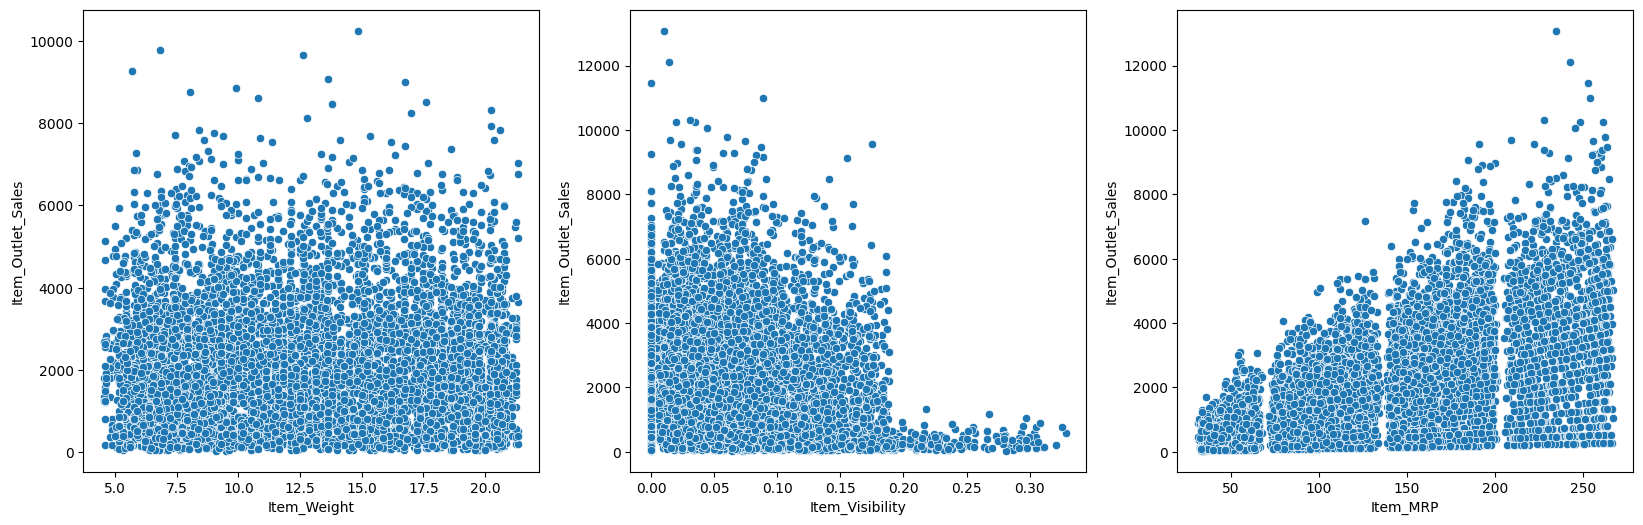

In [18]:
fig, axes = plt.subplots(1, 3, figsize = (20, 6))
sns.scatterplot(x='Item_Weight', y='Item_Outlet_Sales', data=df, ax=axes[0])
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df, ax=axes[1])
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, ax=axes[2])
plt.show()

Let's create a new feature `Outlet_Age` which indicates the outlet's age.

In [19]:

df['Outlet_Age'] = date.today().year - df['Outlet_Establishment_Year']
df.drop('Outlet_Establishment_Year', axis = 1, inplace=True)

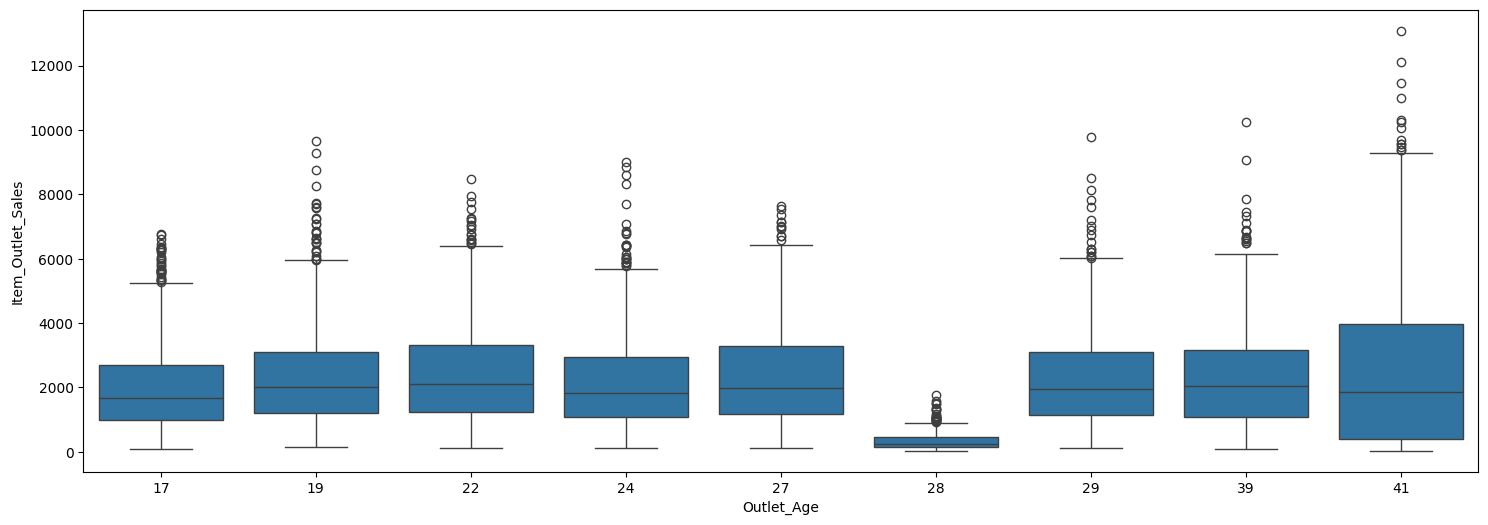

In [20]:
fig = plt.figure(figsize = (18, 6))
sns.boxplot(x = 'Outlet_Age', y = 'Item_Outlet_Sales', data = df)
plt.show()

**Modeling**

In [21]:
# Let's separate dataframe variables: 'X' is for predictors and 'y' is for the response or output variable (Item_Outlet_Sales).
X = df.drop('Item_Outlet_Sales', axis = 1) # pandas.core.frame.DataFrame
y = df['Item_Outlet_Sales']                # pandas.core.series.Series

In [22]:
# Let's split the set in train and test (proportion 80:20)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=1)

In [23]:
# Since it will apply more than one transformer and with a different way (numerical and categorical receive different treatments),
# let's create pipelines (called num_pipeline and cat_pipeline) to transform their coulumns.

# If there were only one transformer for each type of variable, it would not be necessary to create num_pipeline or cat_pipeline.
# The single transformer could go directly into the 'ColumnTransformer' shown below.
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))

preprocessing = ColumnTransformer([
    ('num', num_pipeline, make_column_selector(dtype_include=np.number)),
    ('cat', cat_pipeline, make_column_selector(dtype_include=object))
])

In [24]:
# Next it is not necessary, but it is included to visualize changes produced by the pipeline "preprocessing"
# Notice that now Xtrain has 27 columns after processing, it means it will use 27 predictors in the model (4 numerical and 23 categorical)
Xtrain_prepared = preprocessing.fit_transform(Xtrain)
Xtrain_prepared_df = pd.DataFrame(Xtrain_prepared, columns=preprocessing.get_feature_names_out(), index=Xtrain.index)
Xtrain_prepared_df

,num__Item_Weight,num__Item_Visibility,num__Item_MRP,num__Outlet_Age,cat__Item_Fat_Content_Regular,cat__Item_Type_Breads,cat__Item_Type_Breakfast,cat__Item_Type_Canned,cat__Item_Type_Dairy,cat__Item_Type_Frozen Foods,...,cat__Item_Type_Snack Foods,cat__Item_Type_Soft Drinks,cat__Item_Type_Starchy Foods,cat__Outlet_Size_Medium,cat__Outlet_Size_Small,cat__Outlet_Location_Type_Tier 2,cat__Outlet_Location_Type_Tier 3,cat__Outlet_Type_Supermarket Type1,cat__Outlet_Type_Supermarket Type2,cat__Outlet_Type_Supermarket Type3
1945,0.821375,0.272069,0.681925,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1720,0.761834,0.511783,0.615374,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1954,0.330158,0.164095,0.824788,0.083333,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1919,0.374814,0.496066,0.312702,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2461,0.155701,0.181846,0.423207,0.208333,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,0.479012,0.844906,0.531008,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7813,0.479012,0.542624,0.100619,1.000000,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
905,0.791605,0.200402,0.500067,0.500000,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5192,0.300387,0.151094,0.054833,0.458333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
# Create the pipeline to get the prediction, which includes the preprocessing created previously and the linear regression model.
lr_model = make_pipeline(preprocessing, LinearRegression())
lr_model.fit(Xtrain, ytrain)
predictions = lr_model.predict(Xtest)

print('The Root Mean Square Error (RMSE) is:', root_mean_squared_error(ytest, predictions))
print('The R square (R2) is:', r2_score(ytest, predictions))

The Root Mean Square Error (RMSE) is: 1144.3827848578724
The R square (R2) is: 0.5582080574611583


What would come next is to create more transformations to improve the result. For instance:

* Apply a transformation (log, box-cox, ...) to make `Item_Visibility` a better normal distribution, since it is skewed.

* Use StandarScaler or RobustScaler instead of MinMax.

* Perform OrdinalEncoder to some categorical predictors, instead of OneHotEncoder.

In [26]:
# It is possible to access the steps executed in the pipeline.
lr_model.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('minmaxscaler',
                                                   MinMaxScaler())]),
                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7eeef04258e0>),
                                 ('cat',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehotencoder',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore',
                                                                 sparse_output=False))])

In [27]:
# Once the step is situated, for example the linear regression ('linearregression'), it is possible to access its attributes to show the interception or beta_0
lr_model.named_steps['linearregression'].intercept_

np.float64(274.6134468529333)

In [28]:
# To show the coefficients: beta_1, beta_2, ..., beta_n
# In this case, It got 27 coefficients, one per predictor
lr_model.named_steps['linearregression'].coef_

array([  28.62355263,  -97.09612341, 3678.93686232, -883.7484864 ,
         36.0930557 ,    9.09628309,  -15.7209235 ,   34.68740649,
       -100.45813405,  -39.04913619,   38.07938416,  -23.89284596,
         10.9988591 ,  -62.51983653,  -33.90791199,  -36.06410826,
        283.24072408,   15.10818476,  -74.74109576,   35.98874243,
       -839.68268244, -746.65228891, -202.1755319 , -395.31896407,
       1509.68985198, 1243.4315047 , 3872.29804368])

In [29]:
# To show the transformers executed
lr_model.named_steps['columntransformer']

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7eeef04258e0>),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7eeef05bc680>)])

In [30]:
# To access a particular transformer
lr_model.named_steps['columntransformer'].named_transformers_['num']

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('minmaxscaler', MinMaxScaler())])

In [31]:
# To access the attributes for a particular transformer
# Since it just has 4 numerical predictors, it calculates the minimum for each one.
lr_model.named_steps['columntransformer'].named_transformers_['num'].named_steps['minmaxscaler'].min_

array([-0.27121167,  0.        , -0.13281075, -0.70833333])